# C01 数据入口与可交易资产池


In [ ]:
START_DATE = "2024-01-01"
END_DATE = "2024-12-31"
UNIVERSE = ["000001.XSHE", "000002.XSHE", "600000.XSHG", "510300.XSHG", "000300.XSHG"]
# 000001.XSHE：平安银行（深市 A 股）
# 000002.XSHE：万科A（深市 A 股）
# 600000.XSHG：浦发银行（沪市 A 股）
# 510300.XSHG：沪深300ETF（上交所 ETF）
# 000300.XSHG：沪深300指数（指数，不是单只股票）

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import rqdatac
import warnings
from matplotlib import font_manager

# 配置中文字体，避免标题乱码；同时关闭常见的 glyph 缺失告警
candidate_fonts = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "WenQuanYi Micro Hei", "Arial Unicode MS"]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in candidate_fonts:
    if font_name in available_fonts:
        plt.rcParams["font.sans-serif"] = [font_name]
        break
plt.rcParams["axes.unicode_minus"] = False
warnings.filterwarnings("ignore", message=r"Glyph .* missing from current font")

# 把教育版 license 直接粘贴到 PASSWD
PASSWD = "A9qCyBHTn1oop9PFrEGs0gX_3brK5gWd3U_bl4Xql-1bdZiu5z93MPkoB0-f99GTJYmnDgFawTLm1xypVYxp-uAsGHpN9I4lMlIgKJMxfzFlLdDi_zIsL6Chzv4xjhjLybpw3KlegEPco27BZ5it8gCb53opmnRv1xvM937m0f0=HAf_ZY_gevO08quesn6NLrx9ygL3WCtsoFICUIfRNnVXpzM3a288oZNyWvlt5VahwuPW1Y8MTQflW3XoR9e__1nZARS8VzPlEYcr9tMz7erex--jctwuQYoZDd8CGy5VmMa6bvFKv-kK0dhsbB9M9hK9LKdD3k1opU0JqYrPW7c="

if PASSWD:
    rqdatac.init('license', PASSWD)
    print("rqdatac 初始化成功")
else:
    print("请先填写 PASSWD，再运行本单元")


rqdatac 初始化成功


d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\rqdatac\client.py:263: UserWarning: Your account will be expired after  467 days. Please call us at 0755-22676337 to upgrade or purchase or renew your contract.
  warnings.warn("Your account will be expired after  {} days. "


## 1) 交易数据读取
- `close`、`prev_close`、`volume`
- 使用 `adjust_type='pre'` 观察前复权口径


In [2]:
# 读取交易数据：
# - close: 收盘价
# - prev_close: 交易所口径的“昨收”（会受分红/送转影响）
# - volume: 成交量
#
# 注意：这里用 adjust_type='pre' 是为了让 close 序列在长期上更平滑可比。
# 但 prev_close 的语义仍然是交易所发布的“昨日参考收盘价”，
# 所以它不一定等于“上一行 close”。后面我们会专门演示这一点。
px = rqdatac.get_price(
    UNIVERSE,
    start_date=START_DATE,
    end_date=END_DATE,
    fields=["close", "prev_close", "volume"],
    adjust_type="pre",
    expect_df=True,
)

# 某些返回结构是 MultiIndex（多层索引），reset_index 后更利于后续处理
price_df = px.reset_index() if isinstance(px.index, pd.MultiIndex) else px

# 先做排序，确保后续 groupby + rolling + shift 的时间顺序是正确的
price_df = price_df.sort_values(["order_book_id", "date"]).copy()
price_df.head()


,order_book_id,date,close,prev_close,volume
0,000001.XSHE,2024-01-02,7.992275,9.39,115836645.0
1,000001.XSHE,2024-01-03,7.983597,9.21,73361031.0
2,000001.XSHE,2024-01-04,7.905496,9.20,86419399.0
3,000001.XSHE,2024-01-05,8.044341,9.11,199162216.0
4,000001.XSHE,2024-01-08,7.940208,9.27,112115619.0


## 2) `prev_close` 字段详解与收益计算口径


### 2.1 `prev_close` 和 `adjust_type` 放在一起理解

先说 `prev_close`：
- `prev_close` 不是简单意义上的“上一天 close 原样复制”
- 它是**交易所发布的昨收参考价**

当出现以下事件时，交易所会修正“昨收参考价”：
1. 现金分红
2. 送股 / 转增 / 拆股

因此在除权除息日附近，你可能看到：
- 当天 `prev_close` != 前一行 `close`

这不是数据错，而是字段定义不同。

再说 `adjust_type`：

1. `none`
- 不复权
- 更接近当时真实成交价格
- 最适合讲交易制度字段之间的关系

2. `pre`
- 前复权
- 把历史价格往现在口径调整
- 更适合讲长期走势、技术指标、收益率和回测

3. `post`
- 后复权
- 把后面的价格往过去口径调整
- 也常用于研究累计收益

最关键的一句提醒是：
- 在 `adjust_type='pre'` 下，`close`、`limit_up`、`limit_down` 这些价格类字段可能一起被前复权调整
- 但 `prev_close` 仍然更接近“交易所昨收参考价”的字段语义

所以在前复权表里，不要再直接用：
`limit_up == prev_close * 1.1`

因为这时它们已经不是同一口径了。


In [3]:
# 经典案例：600621 在分红附近日期
# 第一步先看 adjust_type='none'：
example = rqdatac.get_price(
    ["600621.XSHG"],
    start_date="2022-06-16",
    end_date="2022-06-17",
    fields=["prev_close", "close", "limit_up", "limit_down"],
    adjust_type="none",
    expect_df=True,
).reset_index()

example


,order_book_id,date,prev_close,close,limit_up,limit_down
0,600621.XSHG,2022-06-16,12.83,12.00,14.11,11.55
1,600621.XSHG,2022-06-17,11.86,11.78,13.05,10.67


### 2.1 补充观察：同一只股票在 `none / pre` 两种口径下会发生什么

下面这段代码不是在讲收益率，而是在回答一个更基础的问题：

“同一只股票、同一时间段，切换复权口径之后，到底是哪几列被调整了？”

这里重点看：
- `close_none` 和 `close_pre`
- `prev_close_none` 和 `prev_close_pre`

观察完以后再回到上一段总结：
- 为什么 `pre` 口径下不能再用 `prev_close * 1.1` 去验证涨跌停价
- 为什么后面算收益率时必须先统一口径


In [4]:
# 用同一只股票、同一时间段，对比不同复权口径下的价格字段
price_none = rqdatac.get_price(
    ["600621.XSHG"],
    start_date="2022-06-16",
    end_date="2022-06-17",
    fields=["close", "prev_close", "limit_up", "limit_down"],
    adjust_type="none",
    expect_df=True,
).reset_index()

price_pre = rqdatac.get_price(
    ["600621.XSHG"],
    start_date="2022-06-16",
    end_date="2022-06-17",
    fields=["close", "prev_close", "limit_up", "limit_down"],
    adjust_type="pre",
    expect_df=True,
).reset_index()

# 并排展示两种口径，最适合课堂解释“复权到底调整了什么”
adjust_compare = price_none.merge(
    price_pre,
    on=["order_book_id", "date"],
    suffixes=("_none", "_pre"),
)
adjust_compare


,order_book_id,date,close_none,prev_close_none,limit_up_none,limit_down_none,close_pre,prev_close_pre,limit_up_pre,limit_down_pre
0,600621.XSHG,2022-06-16,12.00,12.83,14.11,11.55,11.545877,12.83,13.576027,11.112907
1,600621.XSHG,2022-06-17,11.78,11.86,13.05,10.67,11.468019,11.86,12.704385,10.387417


### 2.2 两种常见收益口径

- `prev_close` 是交易所昨收参考价
- `close` 在不同 `adjust_type` 下可能代表不同价格口径

1. **交易所昨收口径**：`close / prev_close - 1`
   - 优点：贴近交易所字段定义
   - 缺点：与复权 `close` 混用时可能口径不一致

2. **前复权序列口径**（推荐）
   - 先保证 `close` 是前复权序列
   - 再按同一序列做 `shift(1)`：`close / close.shift(1) - 1`

这样能保证收益计算前后口径一致。


In [5]:
# ===== 收益计算：并列展示两种口径 =====

# 口径A：交易所昨收口径（直接用 prev_close）
# 含义：当天收盘价相对“交易所定义的昨收参考价”的变化
price_df["ret_prev_close"] = price_df["close"] / price_df["prev_close"] - 1

# 口径B：前复权序列口径（推荐）
# 做法：在同一个前复权 close 序列中，按资产分组后 shift(1)
# 这样保证分子分母口径一致
price_df["prev_close_pre"] = price_df.groupby("order_book_id")["close"].shift(1)
price_df["ret_pre_shift"] = price_df["close"] / price_df["prev_close_pre"] - 1

# 后续风险指标也使用 ret_pre_shift，保持一致口径
price_df["vol_20"] = (
    price_df.groupby("order_book_id")["ret_pre_shift"]
    .rolling(20)
    .std()
    .reset_index(level=0, drop=True)
)

# 比较两种口径的统计特征
ret_summary = (
    price_df.groupby("order_book_id")[["ret_prev_close", "ret_pre_shift"]]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)
ret_summary


ret_prev_close                         ret_pre_shift          \
                        mean     std     min     max          mean     std   
order_book_id                                                                
000001.XSHE          -0.0913  0.0388 -0.1578 -0.0046        0.0015  0.0165   
000002.XSHE          -0.0011  0.0291 -0.1002  0.1004       -0.0010  0.0291   
000300.XSHG           0.0007  0.0135 -0.0705  0.0848        0.0007  0.0135   
510300.XSHG          -0.0471  0.0146 -0.1311  0.0429        0.0008  0.0142   
600000.XSHG          -0.0460  0.0215 -0.0870  0.0223        0.0021  0.0139   

                               
                  min     max  
order_book_id                  
000001.XSHE   -0.0932  0.0998  
000002.XSHE   -0.1002  0.1004  
000300.XSHG   -0.0705  0.0848  
510300.XSHG   -0.0884  0.0941  
600000.XSHG   -0.0562  0.0533

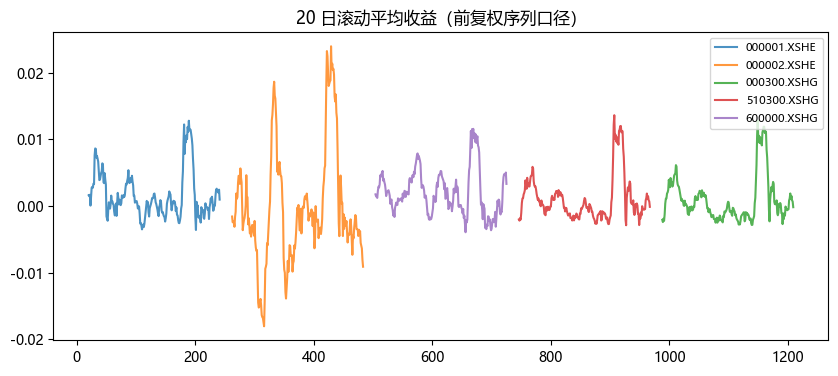

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

# 用推荐口径（ret_pre_shift）画图：
# 这是“同一前复权价格序列”下得到的收益
for asset, grp in price_df.groupby("order_book_id"):
    grp["ret_pre_shift"].rolling(20).mean().plot(ax=ax, alpha=0.8, label=asset)

ax.set_title("20 日滚动平均收益（前复权序列口径）")
ax.legend(loc="upper right", fontsize=8)
plt.show()


### 2.5 单只股票观察：滚动窗口还能算什么

两个简单的因子

1. 20 日均价 `ma20`
2. 20 日平均成交量 `volume_ma20`


In [7]:
# 只取一只股票，单独观察 rolling 的效果
pinan = price_df.loc[price_df["order_book_id"] == "000001.XSHE"].copy()

# 20 日均价：今天往前看 20 个交易日的平均收盘价
pinan["ma20"] = pinan["close"].rolling(20).mean()

# 20 日平均成交量：帮助学生理解 rolling 不只用于收益率
pinan["volume_ma20"] = pinan["volume"].rolling(20).mean()

pinan[["date", "close", "ma20", "volume", "volume_ma20"]].head(25)


,date,close,ma20,volume,volume_ma20
0,2024-01-02,7.992275,NaN,115836645.0,NaN
1,2024-01-03,7.983597,NaN,73361031.0,NaN
2,2024-01-04,7.905496,NaN,86419399.0,NaN
3,2024-01-05,8.044341,NaN,199162216.0,NaN
4,2024-01-08,7.940208,NaN,112115619.0,NaN
5,2024-01-09,7.966241,NaN,76619388.0,NaN
6,2024-01-10,7.888141,NaN,85862091.0,NaN
7,2024-01-11,7.957563,NaN,93468637.0,NaN
8,2024-01-12,7.974919,NaN,77258215.0,NaN
9,2024-01-15,7.992275,NaN,74513266.0,NaN


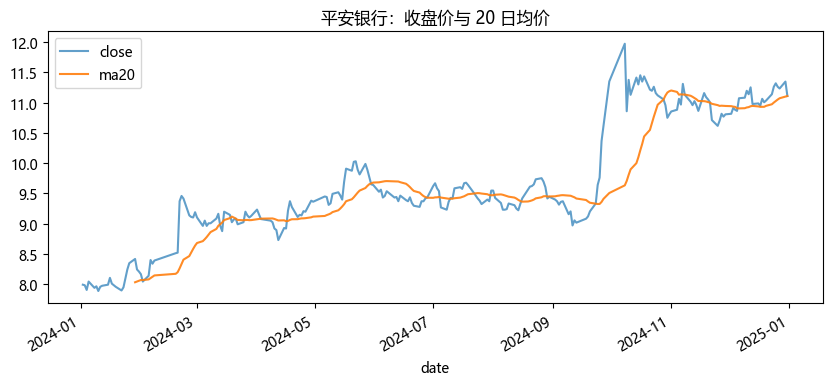

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

# 原始收盘价和 20 日均价放在一张图里， rolling mean 的直观含义
pinan.plot(x="date", y="close", ax=ax, label="close", alpha=0.7)
pinan.plot(x="date", y="ma20", ax=ax, label="ma20", alpha=0.9)

ax.set_title("平安银行：收盘价与 20 日均价")
plt.show()


## 3) 可交易资产池过滤（示例）
- 过滤 ST、停牌
- 过滤低流动性


In [9]:
# 使用股票池来演示过滤逻辑
stock_list = rqdatac.all_instruments(type="stock", date=END_DATE)["order_book_id"].tolist()[:500]

st_flag = rqdatac.is_st_stock(stock_list, start_date=END_DATE, end_date=END_DATE).iloc[0]
sp_flag = rqdatac.is_suspended(stock_list, start_date=END_DATE, end_date=END_DATE).iloc[0]

candidates = [s for s in stock_list if (not st_flag.get(s, False)) and (not sp_flag.get(s, False))]

liq = rqdatac.get_price(
    candidates,
    start_date=rqdatac.get_previous_trading_date(END_DATE, 20),
    end_date=END_DATE,
    fields=["close", "volume"],
    adjust_type="pre",
    expect_df=True,
)

liq = liq.reset_index()
liq["amount"] = liq["close"] * liq["volume"]
avg_amount = liq.groupby("order_book_id")["amount"].mean().sort_values(ascending=False)
tradable_pool = avg_amount.head(100).index.tolist()

pd.Series(tradable_pool, name="tradable_pool").head(20)


0     000063.XSHE
1     000977.XSHE
2     000681.XSHE
3     000564.XSHE
4     000100.XSHE
5     000938.XSHE
6     000066.XSHE
7     000981.XSHE
8     000858.XSHE
9     000158.XSHE
10    000333.XSHE
11    000725.XSHE
12    000988.XSHE
13    000625.XSHE
14    000651.XSHE
15    000568.XSHE
16    000801.XSHE
17    000627.XSHE
18    000001.XSHE
19    000810.XSHE
Name: tradable_pool, dtype: object

## 4) 课上小练习（从 `get_price` 开始）
这两题都从最基础的数据读取接口开始，目的是让大家把“取数 -> 整理 -> 计算”这条链路自己走一遍。

建议做法：先看题目要求自己写，再对照参考答案。


### 练习 1：从 `get_price` 开始，自己用前复权序列计算收益率
要求：
1. 用 `rqdatac.get_price` 获取 `000001.XSHE` 在 `2024-01-01` 到 `2024-03-31` 的 `close`。
2. 用 `reset_index()` 把结果整理成普通表，并按 `order_book_id`、`date` 排序。
3. 用 `groupby("order_book_id")["close"].shift(1)` 自己生成一列 `prev_close_pre`。
4. 新建一列 `ret = close / prev_close_pre - 1`。
5. 展示前 5 行结果。

这题复习的是：`get_price`、`reset_index()`、`groupby()`、`shift()`、新列计算。


In [10]:
# 练习 1：
# 提示：先用 rqdatac.get_price(...) 取前复权 close，再排序、shift，最后生成 ret


In [11]:
# 参考答案
# 第一步：直接从在线接口读取平安银行的前复权收盘价
exercise_1 = rqdatac.get_price(
    ["000001.XSHE"],
    start_date="2024-01-01",
    end_date="2024-03-31",
    fields=["close"],
    adjust_type="pre",
    expect_df=True,
).reset_index()

# 第二步：按股票和日期排序，保证 shift 拿到的是“同一只股票的上一天价格”
exercise_1 = exercise_1.sort_values(["order_book_id", "date"]).copy()

# 第三步：自己在前复权价格序列上构造“上一期收盘价”
exercise_1["prev_close_pre"] = exercise_1.groupby("order_book_id")["close"].shift(1)

# 第四步：按照本节推荐口径，计算基于前复权序列的日收益率
exercise_1["ret_ex1"] = exercise_1["close"] / exercise_1["prev_close_pre"] - 1

# 第五步：展示前几行，检查新列是否生成成功
exercise_1.head()


,order_book_id,date,close,prev_close_pre,ret_ex1
0,000001.XSHE,2024-01-02,7.992275,NaN,NaN
1,000001.XSHE,2024-01-03,7.983597,7.992275,-0.001086
2,000001.XSHE,2024-01-04,7.905496,7.983597,-0.009783
3,000001.XSHE,2024-01-05,8.044341,7.905496,0.017563
4,000001.XSHE,2024-01-08,7.940208,8.044341,-0.012945


### 练习 2：从 `get_price` 开始，自己计算成交额并找出最活跃股票
要求：
1. 先用 `rqdatac.all_instruments(type="stock", date=END_DATE)` 取股票列表，并只保留前 100 只做演示。
2. 用 `rqdatac.get_price` 读取这些股票最近 20 个交易日的 `close` 和 `volume`。
3. 自己生成一列 `amount = close * volume`。
4. 按股票分组，计算 20 日平均成交额，并找出前 10 名。

这题复习的是：`all_instruments`、`get_price`、列运算、`groupby().mean()`、`sort_values()`。


In [12]:
# 练习 2：



In [13]:
# 参考答案
# 第一步：先拿到一个小型股票列表，避免课堂演示太慢
exercise_stock_list = rqdatac.all_instruments(type="stock", date=END_DATE)["order_book_id"].tolist()[:100]

# 第二步：读取最近 20 个交易日的收盘价和成交量
exercise_2 = rqdatac.get_price(
    exercise_stock_list,
    start_date=rqdatac.get_previous_trading_date(END_DATE, 20),
    end_date=END_DATE,
    fields=["close", "volume"],
    adjust_type="pre",
    expect_df=True,
).reset_index()

# 第三步：生成成交额列
exercise_2["amount_ex2"] = exercise_2["close"] * exercise_2["volume"]

# 第四步：按股票求平均成交额，并找出前 10 名
top10_amount = (
    exercise_2.groupby("order_book_id")["amount_ex2"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
top10_amount


order_book_id
000063.XSHE    7.975626e+09
000100.XSHE    3.010536e+09
000066.XSHE    2.895599e+09
000158.XSHE    2.318426e+09
000333.XSHE    2.215002e+09
000001.XSHE    1.301345e+09
000099.XSHE    1.238456e+09
000021.XSHE    1.164541e+09
000002.XSHE    1.039044e+09
000338.XSHE    1.023474e+09
Name: amount_ex2, dtype: float64

## 小结
这一节课虽然还没有正式进入策略，但已经把后面做量化最基础的三件事搭起来了：

1. **会取数**
- 我们已经会用 `rqdatac.get_price` 读取交易数据。
- 也知道了常见字段里，`close`、`prev_close`、`volume` 分别代表什么。

2. **会分辨数据口径**
- `prev_close` 不是简单的“上一行 close”。
- `adjust_type='none' / 'pre' / 'post'` 会影响价格字段的含义。
- 如果要在前复权价格序列上算收益，更稳妥的做法是自己用 `shift()` 构造 `prev_close_pre`。

3. **会做最基础的数据处理**
- 我们已经用过 `sort_values()`、`groupby()`、`shift()`、`rolling()`。
- 这些操作后面会反复出现，不只是第一节课才用。

4. **知道什么叫“可交易资产池”**
- 不是所有股票都适合直接拿来做研究。
- 至少要先过滤 ST、停牌，再过滤流动性太差的股票。
- 我们最后得到的 `tradable_pool`，就是后续因子分析和回测的基础输入之一。

这一节最想让大家记住的一句话是：
> 量化研究不是先写策略，而是先把“数据口径”和“研究对象”定义清楚。

### 本节常见易错点
1. 直接把 `prev_close` 理解成上一行 `close`。
2. 在多只股票混在一起的表里直接 `shift(1)`，没有先 `groupby("order_book_id")`。
3. 价格已经前复权了，却还拿交易制度字段硬做一一对应比较。
4. 没有先做 ST / 停牌 / 流动性过滤，就直接开始策略研究。

### 下节课会做什么
下一节会从“交易数据”往前走一步，开始看财务数据、衍生因子和宏观变量。到那时，`tradable_pool` 就不只是一个列表，而会成为我们构造因子面板、筛选样本和做后续研究的起点。
